In [6]:
import os
from pathlib import Path

import contextily as cx
import geopandas as gpd
import matplotlib.colors as mcol
import matplotlib.pyplot as plt
import numpy as np

from jat_slides.assets.maps.common import add_pop_legend, cmap_rdbu, get_cmap_bounds

In [2]:
population_grids_path = Path(os.environ["POPULATION_GRIDS_PATH"])

In [3]:
df = (
    gpd.read_file(
        population_grids_path / "final" / "differences" / "2000_2020" / "19.1.01.gpkg"
    )
    .set_index("codigo")
    .assign(
        P_11YMENOS_difference=lambda df: df["pop_difference"]
        - df["P_12YMAS_difference"]
    )
)

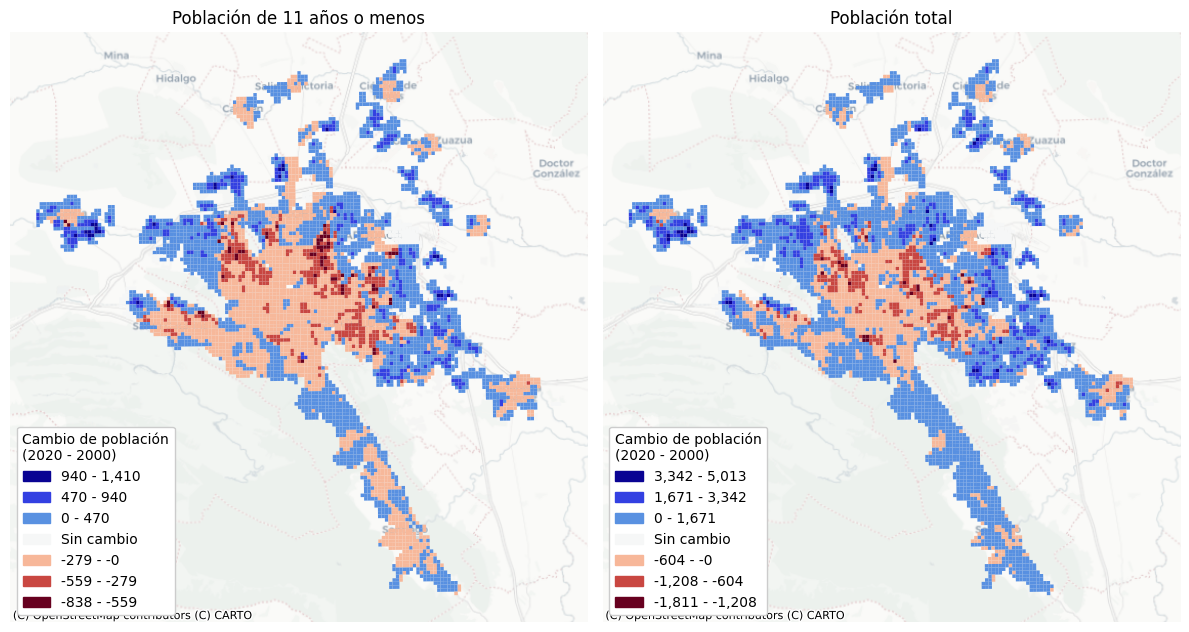

In [4]:
fig, (axl, axr) = plt.subplots(1, 2, figsize=(12, 8))

for ax, col in zip(
    [axl, axr], ["P_11YMENOS_difference", "pop_difference"], strict=True
):
    bounds = get_cmap_bounds(df[col], 3)
    norm = mcol.BoundaryNorm(bounds, 256)

    df.plot(column=col, norm=norm, ax=ax, cmap=cmap_rdbu, ec="k", lw=0, legend=False)
    add_pop_legend(bounds, ax=ax, cmap=cmap_rdbu, legend_pos="lower left")

    ax.axis("off")
    cx.add_basemap(ax, crs=df.crs, source=cx.providers.CartoDB.Positron, zoom=10)

axl.set_title("Población de 11 años o menos")
axr.set_title("Población total")
fig.tight_layout()

In [17]:
temp = (
    df.assign(
        sign_pop=lambda df: np.sign(df["pop_difference"]),
        sign_11ymenos=lambda df: np.sign(df["P_11YMENOS_difference"]),
    )
    .dropna(subset=["sign_pop", "sign_11ymenos"])
    .query("sign_pop != sign_11ymenos")
)

<Axes: >

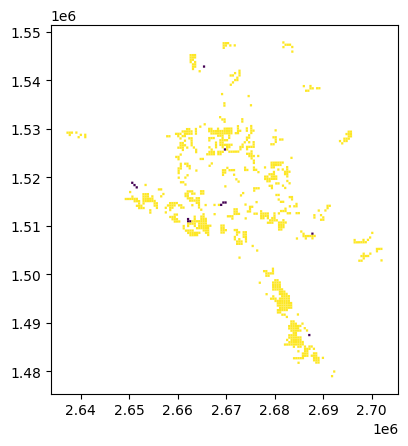

In [19]:
temp.plot(column="sign_pop")